# ACCESS-AIS3 - Development workflow

This workbook presents v0.1 of the ACCESS-AIS3 Antarctic model configuration. Development is completed in this workbook and will be converted/exported to an executable script once complete.

In [1]:
# import sys
# !{sys.executable} -m pip install -e /g/data/au88/lb9857/gitRepos/pyISSM
# !{sys.executable} -m pip install -e /g/data/au88/lb9857/gitRepos/ccdtools

import pyissm
import ccdtools
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
import os

TODO:
- Review BCs - No Dirichlet at this point
- Use relative file paths
- Use MIPKIT rather than individual data files.

In [2]:
## ------------------------------------
## Configure options
## ------------------------------------

# Change directory to gdata to prevent storage limits in $HOME
os.chdir('/g/data/au88/lb9857/access-ais3/')

# Should plots be generated?
plot = False
diagnostics = True
save = True
inversion_sensitivity = False

# Define execution directory
execution_dir = '/g/data/au88/lb9857/access-ais3/execution'

# Define location to save final models
model_dir = '/g/data/au88/lb9857/access-ais3/models'

# Define domain_file
domain_file = ('/g/data/au88/lb9857/gitRepos/ACCESS-AIS3/assets/ais_domain.exp')

# Define param_file
param_file = ('/g/data/au88/lb9857/gitRepos/ACCESS-AIS3/config/ais_0.1_param.py')

# Define cluster requirements
cluster = pyissm.model.classes.cluster.gadi()
cluster.codepath = os.environ['ISSM_DIR']+'/bin'
cluster.executionpath = execution_dir
cluster.storage = 'gdata/au88+gdata/vk83'
cluster.moduleuse = ['/g/data/vk83/modules/']
cluster.moduleload = ['access-issm/2025.11.0']
cluster.np = 32
cluster.memory = 100
cluster.time = 60*48
cluster.login = 'lb9857'
cluster.project = 'au88'

# List all steps for clarity
all_steps = [
    'process_domain',
    'mesh',
    'param',
    'ssa_rheology_floating_inv_sensit'
]

# Define steps to run
# steps = ['process_domain']
# steps = ['mesh', 'param']
steps = ['ssa_rheology_floating_inv_sensit']

In [3]:
## ------------------------------------
## Initialise Data Catalog
## ------------------------------------
catalog = ccdtools.catalog.DataCatalog()
bedmachine_data = catalog.load_dataset('measures_bedmachine_antarctica', version = 'v3')
velocity_data = catalog.load_dataset('measures_insar_based_antarctica_ice_velocity_map', version = 'v2')
measures_coastline = catalog.load_dataset('measures_antarctic_boundaries', subdataset = 'coastline')

In [ ]:
## ------------------------------------
## Process domain file
## ------------------------------------

if 'process_domain' in steps:

    print("-------------------------------------------------------------")
    print(f" PROCESSING DOMAIN FILE"                                     )
    print("-------------------------------------------------------------")

    # Buffer coastline polygon by 100 km
    print(f" - Buffering coastline...")
    coastline_100km_buffer = measures_coastline.buffer(100000)

    # Write buffered extent to file for use as model domain
    print(f" - Saving to file...")
    pyissm.tools.exp.gdf_to_exp(coastline_100km_buffer, '/g/data/au88/gitRepos/ACCESS-AIS3/assets/ais_domain.exp')


In [ ]:
## ------------------------------------
## Create mesh
## ------------------------------------
if 'mesh' in steps:

    print("-------------------------------------------------------------")
    print(f" GENERATING MESH"                                            )
    print("-------------------------------------------------------------")

    # Create empty model with initial 10e3 resolution mesh
    md = pyissm.model.mesh.triangle(pyissm.model.Model(), domain_file, 10e3)
    
    # Remesh the model twice to refine based on velocity and bedmachine mask
    for i in range(2):

        print(f"REFINEMENT ITERATION: {i+1}")

        # Interpolate velocities onto mesh
        print(f"\n-- Interpolating MEaSURES v2 Velocities...")
        vx = pyissm.data.interp.xr_to_mesh(velocity_data, 'VX', md.mesh.x, md.mesh.y)
        vy = pyissm.data.interp.xr_to_mesh(velocity_data, 'VY', md.mesh.x, md.mesh.y)
        vel = np.sqrt(vx**2 + vy**2)

        # Interpolate ice mask onto mesh
        print(f"\n-- Interpolating Bedmachine v3 Ice Mask...")
        mask = pyissm.data.interp.xr_to_mesh(bedmachine_data, 'mask', md.mesh.x, md.mesh.y, interpolation_type = 'nearest')

        # Fill NaN values and set to 0 ice-free areas (and ocean, but over-ridden below)
        print(f"\n-- Set Velocity to 0 where NaNs exist or mask < 2...")
        vel[np.isnan(vel) | (mask < 2)] = 0.0
        
        print(f"\n-- Set Velocity to NaN in ocean areas...")
        vel[(mask < 2)] = np.nan

        if diagnostics:
            print(f"\nVELOCITY DIAGNOSTICS:")
            print(f"    Max velocity: {np.nanmax(vel):.2f} m/yr")
            print(f"    Min velocity: {np.nanmin(vel):.2f} m/yr")
    
        if plot:
            pyissm.plot.plot_model_field(md, vel, cmap = 'PuOr',show_cbar = True, cbar_kwargs = {'label': 'Velocity (m/a)'}); plt.show(block = False)
        
        if diagnostics:
            unique_vals, counts = np.unique(mask, return_counts=True)
            print(f"\nMASK DIAGNOSTICS:")
            for val, count in zip(unique_vals, counts):
                print(f"    Value {val}: {count} occurrences")
        
        if plot:
            pyissm.plot.plot_model_field(md, mask, show_cbar = True, cbar_kwargs = {'label': 'Ice Mask'}); plt.show(block = False)

        # Define min/max vertex lengths in specific regions
        print(f"\n-- Setting min/max vertex dimensions...")
        hmax_v = np.full(md.mesh.numberofvertices, np.nan)
        hmin_v = np.full(md.mesh.numberofvertices, np.nan)
    
        hmax_v[(vel > 50) & (mask == 2)] = 1500 # Max length on fast-flowing grounded ice
        hmin_v[(mask == 3)] = 500 # Min length on ice shelves
        hmax_v[(mask == 3)] = 5000 # Max length on ice shelves
        hmax_v[(mask == 0)] = 5000 # Max length in ocean

        # Adjust mesh with specified metrics
        print(f"\n-- Remeshing with specified metrics...")
        md = pyissm.model.mesh.bamg(md,
                                    hmin = 50,
                                    hmax = 50e3,
                                    hmaxVertices = hmax_v,
                                    hminVertices = hmin_v,
                                    maxnbv = 2e6,
                                    field = vel,
                                    err = 1,
                                    gradation = 1.2)
        
        # Remove bamg private data to allow additional remeshes
        md.private.bamg = {}
    
        if diagnostics:
            print(f"\nMESH DIAGNOSTICS:")
            print(f"   Number of elements: {md.mesh.numberofelements}")
            print(f"   Number of vertices: {md.mesh.numberofvertices}")
    
    # Set georefernce information
    [md.mesh.lat, md.mesh.long] = pyissm.tools.general.xy_to_ll(md.mesh.x, md.mesh.y, -1)
    md.mesh.epsg = 3031
    
    print(f"\nFinal mesh: {md.mesh.numberofvertices} nodes; {md.mesh.numberofelements} elements")
    
    if plot:
        areas = pyissm.model.mesh.get_element_areas_volumes(md.mesh.elements, md.mesh.x, md.mesh.y)
        # A = l^2 * sqrt(3) / 4 is area for equilateral triangle
        # np.sqrt(A*2) / 1e3 is the rough approximation of element edge length in km
        fig, ax = pyissm.plot.plot_model_field(md,
                                               np.sqrt(areas*2)/1e3,
                                               show_cbar = True,
                                               vmin = 0.25,
                                               vmax = 10,
                                               plot_data_on='elements',
                                               cmap = 'plasma_r',
                                               cbar_kwargs = {'label': 'Approx. element edge length (km)'})
        ax.set_title('Final Mesh: Velocity-adapted w/ 2 refinement passes')
        plt.show(block = False)

    if save:
        print(f"\nSaving model to {model_dir}/AIS3_mesh.nc")
        pyissm.model.io.save_model(md, f'{model_dir}/AIS3_mesh.nc')

In [ ]:
## ------------------------------------
## Parameterise model
## ------------------------------------
if 'param' in steps:

    print("-------------------------------------------------------------")
    print(f" PARAMETERIZING MODEL"                                       )
    print("-------------------------------------------------------------")

    print(f"-- Loading model mesh...")
    md = pyissm.model.io.load_model(f'{model_dir}/AIS3_mesh.nc')

    print(f"-- Parameterising model using {param_file}...")
    md = pyissm.model.param.parameterize(md, param_file)

    print(f"-- Set flow equation to SSA...")
    md = pyissm.model.param.set_flow_equation(md, SSA = 'all')


    print(f"-- Setting Boundary Conditions...")
    # -------- Set Stress Balance BCs --------
    ## Initialize empty fields
    md.stressbalance.spcvx = np.nan * np.ones(md.mesh.numberofvertices)
    md.stressbalance.spcvy = np.nan * np.ones(md.mesh.numberofvertices)
    md.stressbalance.spcvz = np.nan * np.ones(md.mesh.numberofvertices)
    
    ## Find ice nodes on the edge of the domain 
    pos = (md.mask.ice_levelset < 0) & (md.mesh.vertexonboundary.astype(bool))
    
    ## Set Dirichlet BCs on VX and VY fields based on initial velocities; Set VZ as 0
    md.stressbalance.spcvx[pos] = md.initialization.vx[pos]
    md.stressbalance.spcvy[pos] = md.initialization.vy[pos]
    md.stressbalance.spcvz[pos] = 0 #TODO: Specify this here?

    md.stressbalance.referential = np.nan * np.ones((md.mesh.numberofvertices, 6))
    md.stressbalance.loadingforce = np.zeros((md.mesh.numberofvertices, 3))

    # -------- Set thermal Balance BCs --------
    md.thermal.spctemperature = md.initialization.temperature.copy()
  

    if diagnostics:
        print(f"\nMASK DIAGNOSTICS:")
        print(f" - Ice Levelset:")        
        unique_vals, counts = np.unique(md.mask.ice_levelset, return_counts=True)
        for val, count in zip(unique_vals, counts):
            print(f"    Value {val}: {count} occurrences")

        print(f" Ocean Levelset (Binary):")
        ocean_binary = md.mask.ocean_levelset <= 0
        unique_vals, counts = np.unique(ocean_binary, return_counts=True)
        for val, count in zip(unique_vals, counts):
            print(f"    Value {val}: {count} occurrences")

        print(f"\nGEOMETRY DIAGNOSTICS:")
        print(f" - Surface elevation:")
        print(f"   min = {np.min(md.geometry.surface):.2f} m")
        print(f"   max = {np.max(md.geometry.surface):.2f} m")
        print(f" - Bed elevation:")
        print(f"   min = {np.min(md.geometry.bed):.2f} m")
        print(f"   max = {np.max(md.geometry.bed):.2f} m")
        print(f" - Thickness:")
        print(f"   min = {np.min(md.geometry.thickness):.2f} m")
        print(f"   max = {np.max(md.geometry.thickness):.2f} m")

        print(f"VELOCITY DIAGNOSTICS:")
        print(f"   Min observed vx: {np.min(md.inversion.vx_obs):.2f} m/yr")
        print(f"   Max observed vx: {np.max(md.inversion.vx_obs):.2f} m/yr")
        print(f"   Min observed vy: {np.min(md.inversion.vy_obs):.2f} m/yr")
        print(f"   Max observed vy: {np.max(md.inversion.vy_obs):.2f} m/yr")
        print(f"   Min observed vel: {np.min(md.inversion.vel_obs):.2f} m/yr")
        print(f"   Max observed vel: {np.max(md.inversion.vel_obs):.2f} m/yr")

        print(f"INITIAL PRESSURE DIAGNOSTICS:")
        print(f"   Min initial pressure: {np.min(md.initialization.pressure):.2f} Pa")
        print(f"   Max initial pressure: {np.max(md.initialization.pressure):.2f} Pa")

        print(f"GEOTHERMAL HEAT FLOW DIAGNOSTICS:")
        print(f"   Min geothermal heat flux: {np.min(md.basalforcings.geothermalflux):.7f} mW/m2")
        print(f"   Max geothermal heat flux: {np.max(md.basalforcings.geothermalflux):.7f} mW/m2")

        print(f"INITIAL TEMPERATURE DIAGNOSTICS:")
        print(f"   Min initial temp: {np.min(md.initialization.temperature):.2f} K")
        print(f"   Max initial temp: {np.max(md.initialization.temperature):.2f} K")

    if save:
        print(f"\nSaving model to {model_dir}/AIS3_param.nc")
        pyissm.model.io.save_model(md, f'{model_dir}/AIS3_param.nc')

In [32]:
## ------------------------------------
## SSA Rheology Inversion Sensitivity - Floating Ice
## ------------------------------------
if 'ssa_rheology_floating_inv_sensit' in steps:
    
    print("-------------------------------------------------------------")
    print(f" SSA RHEOLOGY INVERSION SENSITIVITY - FLOATING ICE"          )
    print("-------------------------------------------------------------")
    
    print(f"-- Loading parameterized model...")
    md = pyissm.model.io.load_model(f'{model_dir}/AIS3_param.nc')
    
    print(f"-- Define general control parameters...")
    md.inversion.iscontrol = 1
    md.verbose.solution = 0
    md.verbose.qmu = 0
    md.verbose.control = 1

    print(f"-- Defining inversion parameters...")
    md.inversion = pyissm.model.classes.inversion.m1qn3(md.inversion)
    md.inversion.iscontrol = 1
    md.inversion.control_parameters = ['MaterialsRheologyBbar']
    md.inversion.min_parameters = pyissm.tools.materials.cuffey(273.15 - 0) * np.ones((md.mesh.numberofvertices, ))
    md.inversion.max_parameters = pyissm.tools.materials.cuffey(273.15 - 70) * np.ones((md.mesh.numberofvertices, ))
    md.inversion.maxsteps = 500
    md.inversion.maxiter = 200

    # Remove icebergs
    print('-- Removing icebergs from ice levelset...')
    md.mask.ice_levelset = pyissm.model.param.kill_icebergs(md)

    print('-- Extracting floating ice only...')
    mask = (md.mask.ocean_levelset < 0) & (md.mask.ice_levelset < 0) # Floating ice
    mds = md.extract(mask)

    # print(f"-- Extracting floating ice only (including ice-front)...")
    # # Move ice and ocean mask to elements to capture ice-front
    # ice_levelset_elements = pyissm.tools.interp.vertex_to_element(md, md.mask.ice_levelset)
    # ocean_levelset_elements = pyissm.tools.interp.vertex_to_element(md, md.mask.ocean_levelset)
    # mds = md.extract((ice_levelset_elements < 1) & (ocean_levelset_elements < 1))

    # print(f"-- Update BCs to ensure Neumann BCs on ice-front...")
    # # Update boundary conditions for Neumann BCs on ice-front.
    # # NOTE: This is essential to ensure consistent results between
    # # inversion and subsequent stressbalance. Since extract() adds Dirichlet
    # # BCs around the entire boundary, by default. This is not consistent
    # # with the BCs at the ice-front in the main domain, so make them
    # # consistent here.
    # iceFront = mds.mask.ice_levelset >= 0
    # mds.stressbalance.spcvx[iceFront] = np.nan
    # mds.stressbalance.spcvy[iceFront] = np.nan
    # mds.stressbalance.spcvz[iceFront] = np.nan

    print(f"-- Assigning cluster and updating settings...")
    mds.cluster = cluster
    mds.settings.waitonlock = 0
    mds.stressbalance.restol  = 0.001
    mds.stressbalance.reltol  = 0.01

    print(f"-- Setting-up coefficient grid...")
    param_grid = pyissm.inversion.sensitivity.build_parameter_grid(
        {101: [1, 10, 100, 1000],
         103: [1, 10, 100, 1000]})
    
    # print(f"-- Defining mask to exclude 0 velocity and iceFront areas from inversion...")
    # mask = (mds.inversion.vel_obs > 0) & (~iceFront)
    print(f"-- Defining mask to exclude 0 velocity from inversion...")
    mask = (mds.inversion.vel_obs > 0)

    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
    # pyissm.plot.plot_model_bc(mds, ax = ax1)
    # pyissm.plot.plot_model_field(mds, mask, show_cbar = True, ax = ax2)
    
    print(f"-- Running inversion parameter sensitivity...")
    manifest = pyissm.inversion.sensitivity.parameter_sensitivity(
        mds,
        param_grid,
        output_dir = f'{model_dir}/ssa_rheology_floating_inv_sensit',
        run = False,
        load_only = True,
        global_mask = mask)


-------------------------------------------------------------
 SSA RHEOLOGY INVERSION SENSITIVITY - FLOATING ICE
-------------------------------------------------------------
-- Loading parameterized model...
-- Define general control parameters...
-- Defining inversion parameters...
-- Removing icebergs from ice levelset...
Looking for isolated patches of floating ice (icebergs)
   -- iteration 1
   -- iteration 2
   -- iteration 3
   -- iteration 4
   -- iteration 5
   -- iteration 6
   -- iteration 7
   -- iteration 8
   -- iteration 9
   -- iteration 10
   -- iteration 11
   -- iteration 12
   -- iteration 13
   -- iteration 14
   -- iteration 15
   -- iteration 16
   -- iteration 17
   -- iteration 18
   -- iteration 19
   -- iteration 20
   -- iteration 21
   -- iteration 22
   -- iteration 23
   -- iteration 24
   -- iteration 25
   -- iteration 26
   -- iteration 27
   -- iteration 28
   -- iteration 29
   -- iteration 30
   -- iteration 31
   -- iteration 32
   -- iteration 33

In [5]:
## Process diagnostics
manifest = pd.read_csv('/g/data/au88/lb9857/access-ais3/models/ssa_rheology_floating_inv_sensit/manifest.csv')
diagnostics = pyissm.inversion.sensitivity.compute_sensitivity_diagnostics(manifest, output_dir='/g/data/au88/lb9857/access-ais3/models/ssa_rheology_floating_inv_sensit/')

Processing diagnostics: run_0000_1_1
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0001_1_10
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0002_1_100
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0003_1_1000
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0004_10_1
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0005_10_10
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0006_10_100
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0007_10_1000
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0008_100_1
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0009_100_10
ℹ️ Processing results group: StressbalanceSolution
Processing diagnostics: run_0010_100_100
ℹ️ Processing results group: StressbalanceSolution
Process

<Axes: title={'center': 'overall'}, xlabel='cf101', ylabel='cf103'>

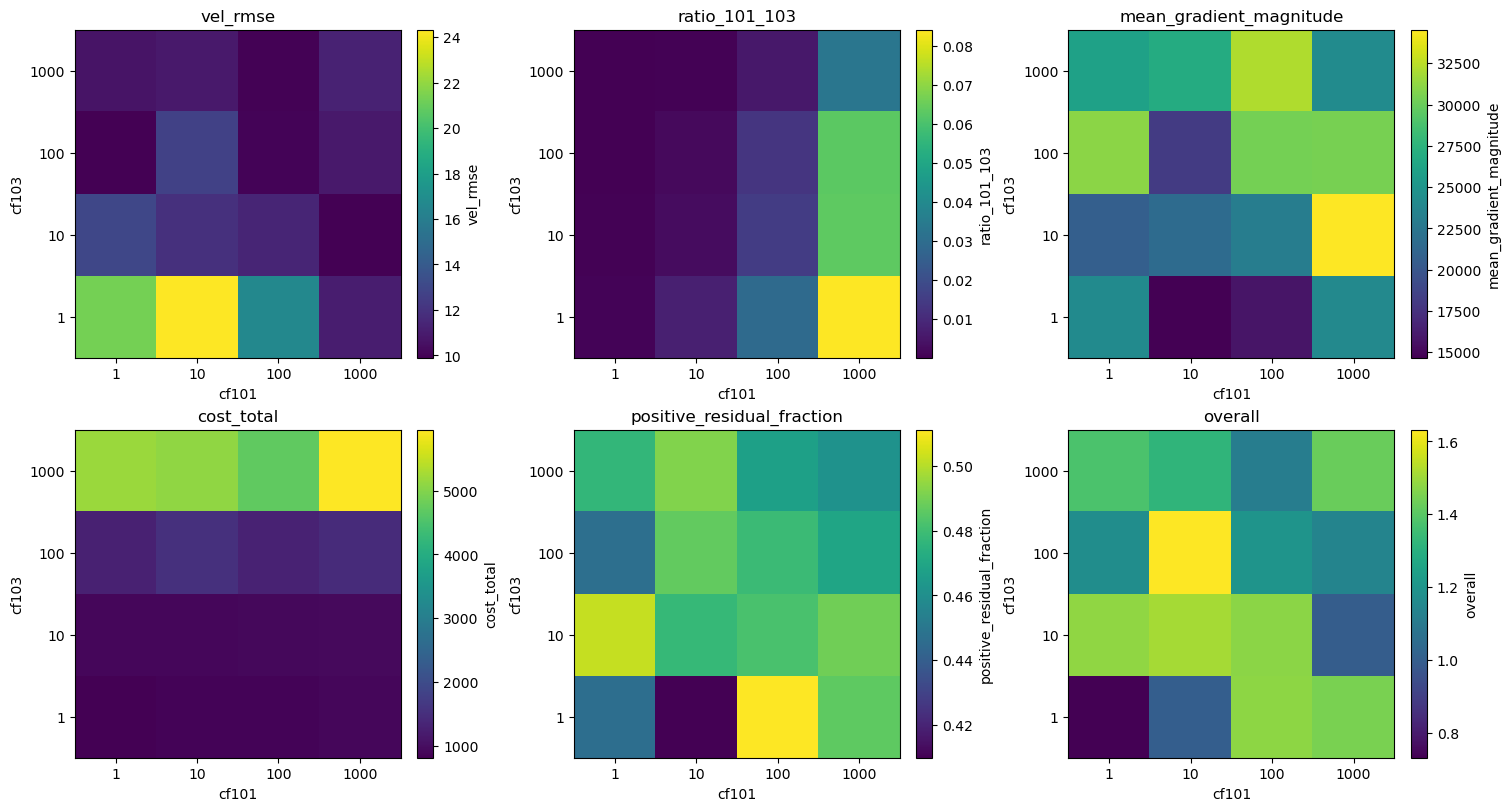

In [6]:
manifest = pd.read_csv('/g/data/au88/lb9857/access-ais3/models/ssa_rheology_floating_inv_sensit/manifest.csv')
diagnostics = pd.read_csv('/g/data/au88/lb9857/access-ais3/models/ssa_rheology_floating_inv_sensit/diagnostics.csv')

# Normalize diagnostics (0-1)
diagnostics_norm = pyissm.inversion.sensitivity.normalize_diagnostics(diagnostics,
                                                                     columns = ['vel_rmse', 'mean_gradient_magnitude'])

# Plot heatmaps of select diagnostic values
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize = (15, 8), constrained_layout = True)
pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax1,
                                               value = 'vel_rmse')

pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax2,
                                               value = 'ratio_101_103')

pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax3,
                                               value = 'mean_gradient_magnitude')

pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax4,
                                               value = 'cost_total')

pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax5,
                                               value = 'positive_residual_fraction')

diagnostics_norm['overall'] = diagnostics_norm['vel_rmse_norm'] + diagnostics_norm['mean_gradient_magnitude_norm']
pyissm.inversion.plot.plot_sensitivity_heatmap(diagnostics_norm,
                                               x = 'cf101',
                                               y = 'cf103',
                                               ax = ax6,
                                               value = 'overall')


In [27]:
diagnostics_norm.sort_values('overall', ascending = False)

,run_id,run_name,run_dir,execution_path,run_status,cf101,cf103,vel_rmse,cost_101,cost_103,...,positive_residual_area,negative_residual_area,positive_residual_fraction,negative_residual_fraction,mean_gradient_magnitude,rmse_gradient_magnitude,diagnostics_status,vel_rmse_norm,mean_gradient_magnitude_norm,overall
6,6,run_0006_10_100,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,10,100,12.692772,3.540653,1525.933945,...,6.665844e+11,7.020135e+11,0.487056,0.512944,18129.528967,38895.562441,complete,0.806249,0.825823,1.632072
5,5,run_0005_10_10,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,10,10,11.893636,2.657344,902.905202,...,6.540910e+11,7.145069e+11,0.477928,0.522072,21635.827176,51725.299370,complete,0.861613,0.649322,1.510935
1,1,run_0001_1_10,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,1,10,12.960791,0.394005,912.727476,...,6.877084e+11,6.808895e+11,0.502491,0.497509,20698.743743,50590.726423,complete,0.787681,0.696493,1.484174
8,8,run_0008_100_1,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,100,1,16.607370,24.427593,842.999717,...,6.997092e+11,6.688887e+11,0.511260,0.488740,15814.725831,38200.682867,complete,0.535046,0.942347,1.477393
9,9,run_0009_100_10,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,100,10,11.391173,13.665271,907.092941,...,6.596200e+11,7.089779e+11,0.481968,0.518032,23060.604990,52778.813275,complete,0.896424,0.577601,1.474025
12,12,run_0012_1000_1,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,1000,1,11.047180,70.676161,839.874606,...,6.654779e+11,7.031199e+11,0.486248,0.513752,23997.062025,49016.519826,complete,0.920256,0.530461,1.450717
15,15,run_0015_1000_1000,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,1000,1000,11.255934,191.444886,5765.300663,...,6.314767e+11,7.371212e+11,0.461404,0.538596,24215.210093,51319.276903,complete,0.905793,0.519480,1.425273
3,3,run_0003_1_1000,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,1,1000,10.638785,0.338124,5173.345472,...,6.529006e+11,7.156973e+11,0.477058,0.522942,26010.521777,55102.693604,complete,0.948549,0.429106,1.377656
7,7,run_0007_10_1000,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,10,1000,10.869122,3.055737,5101.859946,...,6.732855e+11,6.953124e+11,0.491953,0.508047,26863.053535,56834.309040,complete,0.932592,0.386191,1.318783
10,10,run_0010_100_100,/g/data/au88/lb9857/access-ais3/models/ssa_rhe...,/g/data/au88/lb9857/access-ais3/execution,completed,100,100,10.056067,16.565251,1281.890025,...,6.555920e+11,7.130059e+11,0.479025,0.520975,30378.081135,65818.682037,complete,0.988920,0.209250,1.198170


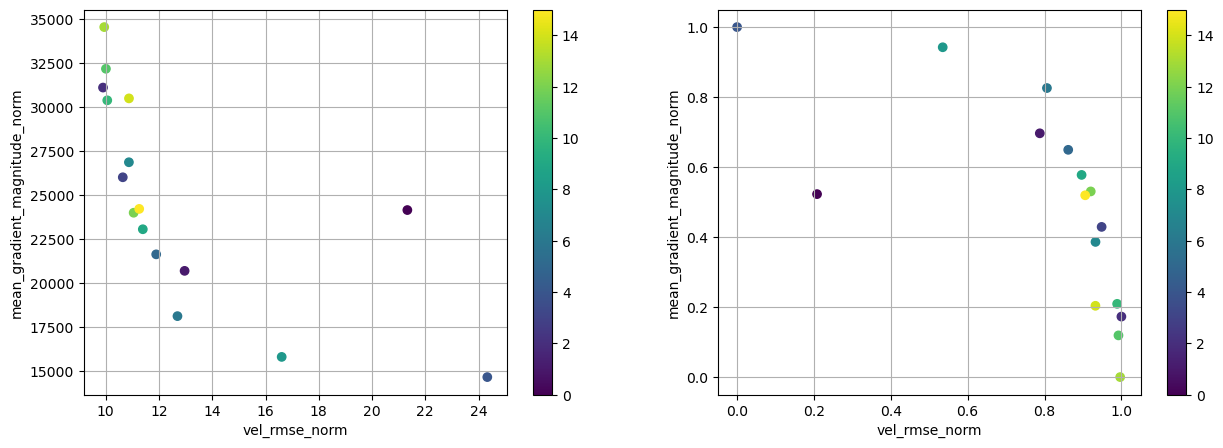

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
raw = ax1.scatter(diagnostics_norm['vel_rmse'], diagnostics_norm['mean_gradient_magnitude'], c = diagnostics_norm['run_id'])
ax1.grid()
ax1.set_xlabel('vel_rmse_norm')
ax1.set_ylabel('mean_gradient_magnitude_norm')
plt.colorbar(raw, ax = ax1)

norm = ax2.scatter(diagnostics_norm['vel_rmse_norm'], diagnostics_norm['mean_gradient_magnitude_norm'], c = diagnostics_norm['run_id'])
ax2.grid()
ax2.set_xlabel('vel_rmse_norm')
ax2.set_ylabel('mean_gradient_magnitude_norm')
plt.colorbar(norm, ax = ax2)

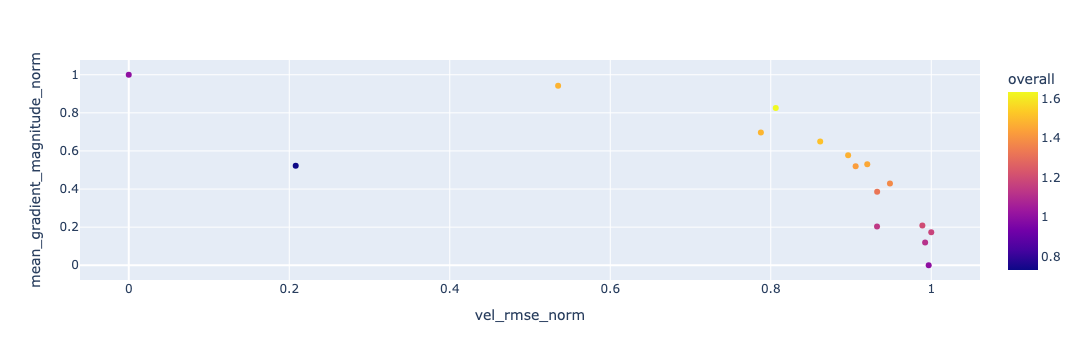

In [30]:
import plotly.express as px

fig = px.scatter(
    diagnostics_norm,
    x='vel_rmse_norm',
    y='mean_gradient_magnitude_norm',
    color='overall',
    hover_data=[
        'run_id',
        'vel_rmse',
        'mean_gradient_magnitude',
    ],
)

fig.show()

ℹ️ Processing results group: StressbalanceSolution


Text(0.5, 1.0, 'Inverted Rheology B')

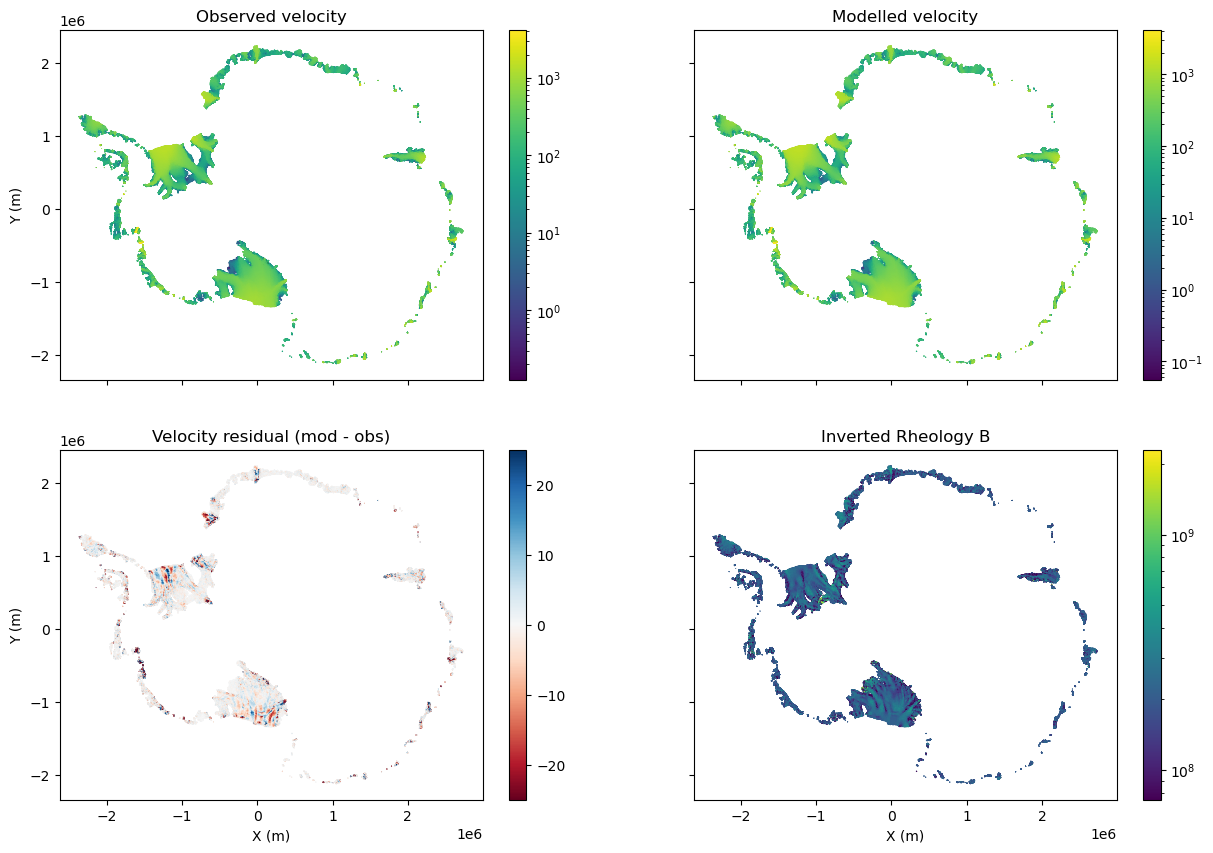

In [31]:
## Load run6, the "best" model
run6 = pyissm.inversion.sensitivity.load_parameter_sensitivity_run(manifest.iloc[6])
res = pyissm.tools.diagnostics.velocity_residuals(run6)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (15, 10), sharex = True, sharey = True)
pyissm.plot.plot_model_field(run6,
                             run6.inversion.vel_obs,
                             show_cbar = True,
                             log = True,
                             xlabel = '',
                             ax = ax1)
ax1.set_title('Observed velocity')

pyissm.plot.plot_model_field(run6,
                             run6.results.StressbalanceSolution.Vel,
                             show_cbar = True,
                             log = True,
                             xlabel = '',
                             ylabel = '',
                             ax = ax2)
ax2.set_title('Modelled velocity')

pyissm.plot.plot_model_field(run6,
                             res,
                             show_cbar = True,
                             cmap = 'RdBu',
                             vmin = -25,
                             vmax = 25,
                             ax = ax3)
ax3.set_title('Velocity residual (mod - obs)')

pyissm.plot.plot_model_field(run6,
                             run6.results.StressbalanceSolution.MaterialsRheologyBbar,
                             log = True,
                             show_cbar = True,
                             ylabel = '',
                             ax = ax4)
ax4.set_title('Inverted Rheology B')

In [ ]:
## ------------------------------------
## Extrude model
## ------------------------------------
if 'extrude' in steps:

    print("-------------------------------------------------------------")
    print(f" EXTRUDING MODEL"                                       )
    print("-------------------------------------------------------------")

    print(f"-- Loading parameterized model...")
    md = pyissm.model.io.load_model(f'{execution_dir}/AIS3_param.nc')

    print(f"-- Extruding model to 3D...")
    md = md.extrude(10, 1.1)

    print(f"-- Set flow equation to HO...")
    md = pyissm.model.param.set_flow_equation(md, HO = 'all')

    if save:
        print(f"\nSaving model to {execution_dir}/AIS3_extrude.nc")
        pyissm.model.io.save_model(md, f'{execution_dir}/AIS3_extrude.nc')

In [ ]:
## ------------------------------------
## HO Rheology Inversion - Floating Ice
## ------------------------------------
if 'ho_rheology_floating_inv' in steps:
    
    print("-------------------------------------------------------------")
    print(f" HO RHEOLOGY INVERSION - FLOATING ICE"                       )
    print("-------------------------------------------------------------")
    
    print(f"-- Loading extruded model...")
    md = pyissm.model.io.load_model(f'{execution_dir}/AIS3_extrude.nc')
    
    print(f"-- Define general control parameters...")
    md.inversion.iscontrol = 1
    md.verbose.solution = 0
    md.verbose.qmu = 0
    md.verbose.control = 1
    
    # Run inversion_sensitivity process to select optimal inversion parameters
    if inversion_sensitivity:
        warning.warn(f"inversion_sensitivity functionality is not yet implemented. Set inversion_sensitivity = False to run inversion with best-guess.")
    else:    
        print(f"-- Defining inversion parameters...")
        md.inversion = pyissm.model.classes.inversion.m1qn3(md.inversion)
        md.inversion.iscontrol = 1
        md.inversion.control_parameters = ['MaterialsRheologyBbar']
        md.inversion.cost_functions = [101, 103, 502]
        md.inversion.cost_functions_coefficients = np.ones((md.mesh.numberofvertices, 3))
        md.inversion.cost_functions_coefficients[:, 0] = 2000
        md.inversion.cost_functions_coefficients[:, 1] = 40
        md.inversion.cost_functions_coefficients[:, 2] = 1e-16
        pos = md.inversion.vel_obs == 0
        md.inversion.cost_functions_coefficients[pos, 0:2] = 0 # Column index is exclusive, so 0:2 sets both 0 and 1 to zero
        md.inversion.min_parameters = pyissm.tools.materials.cuffey(273.15 - 0) * np.ones((md.mesh.numberofvertices, ))
        md.inversion.max_parameters = pyissm.tools.materials.cuffey(273.15 - 70) * np.ones((md.mesh.numberofvertices, ))
        md.inversion.maxsteps = 500
        md.inversion.maxiter = 200
    
        print(f"-- Extracting floating ice only...")
        mask = (md.mask.ocean_levelset < 0) & (md.mask.ice_levelset < 0)
        mds = md.extract(mask)
    
        print(f"-- Assigning cluster and updating settings...")
        mds.cluster = cluster
        mds.settings.waitonlock = 0
        mds.miscellaneous.name = 'AIS3_ho_rheology_floating_inv'
    
        # Solve inversion
        if save:
            print(f"\nSaving model to {execution_dir}/AIS3_ho_rheology_floating_inv.nc")
            mds = pyissm.model.execute.solve(mds, 'Stressbalance', load_only = True, runtime_name = False)
            pyissm.model.io.save_model(mds, f'{execution_dir}/AIS3_ho_rheology_floating_inv.nc')
    
        else:
            print(f"-- Running HO Rheology B inversion on floating ice...")    

            print(f"-- Setting temporary fixes")   
            mds.basalforcings.groundedice_melting_rate = np.full(mds.mesh.numberofvertices, 0)
            mds.basalforcings.floatingice_melting_rate = np.full(mds.mesh.numberofvertices, 0)
            
            mds = pyissm.model.execute.solve(mds, 'Stressbalance', load_only = False, runtime_name = False)


In [ ]:
## ------------------------------------
## HO Friction Inversion
## ------------------------------------
if 'ho_friction_inv' in steps:
    
    print("-------------------------------------------------------------")
    print(f" HO FRICTION INVERSION"                                      )
    print("-------------------------------------------------------------")
    
    print(f"-- Loading extruded model...")
    md = pyissm.model.io.load_model(f'{execution_dir}/AIS3_extrude.nc')

    print(f"-- Loading HO floating rheology inversion results...")
    mds = pyissm.model.io.load_model(f'{execution_dir}/AIS3_ho_rheology_floating_inv.nc')

    print(f"-- Updating rheology field from inversion results...")
    md.materials.rheology_B[mds.mesh.extractedvertices - 1] = mds.results.StressbalanceSolution.MaterialsRheologyBbar # Note: -1 for zero-based indexing

    print(f"-- Removing icebergs from ice levelset...")
    ## TOOD: Is this necessary if there are no Dirichlet BCs specified?
    md.mask.ice_levelset = pyissm.model.param.kill_icebergs(md)
    # Constrain nodes with no ice
    pos = md.mask.ice_levelset > 0
    md.stressbalance.spcvx[pos] = md.inversion.vx_obs[pos].copy()
    md.stressbalance.spcvy[pos] = md.inversion.vy_obs[pos].copy()
    md.stressbalance.spcvz[pos] = 0.

    print(f"-- Define general control parameters...")
    md.inversion.iscontrol = 1
    md.verbose.solution = 0
    md.verbose.qmu = 0
    md.verbose.control = 1
    
    # Run inversion_sensitivity process to select optimal inversion parameters
    if inversion_sensitivity:
        warning.warn(f"inversion_sensitivity functionality is not yet implemented. Set inversion_sensitivity = False to run inversion with best-guess.")
    else:    
        print(f"-- Defining inversion parameters...")
        md.inversion = pyissm.model.classes.inversion.m1qn3(md.inversion)
        md.inversion.iscontrol = 1
        md.inversion.control_parameters = ['FrictionC']
        md.inversion.cost_functions = [101, 103, 501]
        md.inversion.cost_functions_coefficients = np.ones((md.mesh.numberofvertices, 3))
        md.inversion.cost_functions_coefficients[:, 0] = 9000
        md.inversion.cost_functions_coefficients[:, 1] = 40
        md.inversion.cost_functions_coefficients[:, 2] = 1.6e-6
        pos = (md.mask.ice_levelset > 0) | (md.inversion.vel_obs == 0)
        md.inversion.cost_functions_coefficients[pos, 0:2] = 0 # Column index is exclusive, so 0:2 sets 0, 1 to 0
        md.inversion.min_parameters = np.full(md.mesh.numberofvertices, 0.05)
        md.inversion.max_parameters = np.full(md.mesh.numberofvertices, 250^2) ## TODO: Set upper bound once better constrained
        md.inversion.maxsteps = 500
        md.inversion.maxiter = 200

        # Set no friction under ENTIRELY ocean elements
        ocean_elements = md.mask.ocean_levelset[md.mesh.elements - 1] # -1 for zero-based indexing
        pos_e = np.where(np.min(ocean_elements, axis = 1) < 0)[0]
        flags = np.zeros(md.mesh.numberofvertices, dtype=bool)
        flags[md.mesh.elements[pos_e, :] - 1] = True # -1 for zero-based indexing
        md.friction.coefficient[flags] = 0
        md.inversion.min_parameters[flags] = 0
        md.inversion.max_parameters[flags] = 0
    
        print(f"-- Assigning cluster and updating settings...")
        md.cluster = cluster
        md.settings.waitonlock = 0
        md.miscellaneous.name = 'AIS3_ho_friction_inv'
    
        # Solve inversion
        if save:
            print(f"\nSaving model to {execution_dir}/AIS3_ho_friction_inv.nc")
            md = pyissm.model.execute.solve(md, 'Stressbalance', load_only = True, runtime_name = False)
            pyissm.model.io.save_model(md, f'{execution_dir}/AIS3_ho_friction_inv.nc')
    
        else:
            print(f"-- Running HO friction inversion...")                
            md = pyissm.model.execute.solve(md, 'Stressbalance', load_only = False, runtime_name = False)
